Uploading the electric vehicle population dataset from googledrive to colab with the correct library

In [15]:
import pandas as pd
path = "/content/drive/MyDrive/Electric_Vehicle_Population_Data.csv"
df= pd.read_csv(path)
df.head()
df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279775,3GPKHXRJ8R,Clark,Washougal,WA,98671.0,2024,HONDA,PROLOGUE,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,18.0,276754432,POINT (-122.35341 45.57923),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
279776,WBY8P8C51K,King,Seattle,WA,98103.0,2019,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,126.0,36.0,280708333,POINT (-122.35436 47.67596),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
279777,7PDSGCBA3T,King,Sammamish,WA,98075.0,2026,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,41.0,286565541,POINT (-122.03539 47.61344),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
279778,7SAYGDED2T,Pierce,Bonney Lake,WA,98391.0,2026,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,31.0,288480419,POINT (-122.17144 47.19175),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10


In [16]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,279756.000000,279780.000000,279769.000000,279080.000000,2.797800e+05,2.797560e+05
mean,98176.111447,2022.074072,39.172256,28.827841,2.462994e+08,5.297189e+10
std,2577.398040,3.059852,78.230356,14.908133,6.346205e+07,1.636194e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.213867e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.629453e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.790832e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [18]:
df['Model']

,Model
0,LEAF
1,SOLTERRA
2,LEAF
3,X5
4,500
...,...
279775,PROLOGUE
279776,I3
279777,R1S
279778,MODEL Y


In [19]:
df.isnull().sum()

,0
VIN (1-10),0
County,24
City,24
State,0
Postal Code,24
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279780 entries, 0 to 279779
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         279780 non-null  object 
 1   County                                             279756 non-null  object 
 2   City                                               279756 non-null  object 
 3   State                                              279780 non-null  object 
 4   Postal Code                                        279756 non-null  float64
 5   Model Year                                         279780 non-null  int64  
 6   Make                                               279780 non-null  object 
 7   Model                                              279780 non-null  object 
 8   Electric Vehicle Type                              279780 non-null  object

In [21]:
df['Electric Vehicle Type'].nunique()

2

Unique count for counties

In [22]:
df['County'].nunique()

253

Unique count for makes

In [23]:
df['Make'].nunique()

47

In [24]:
df['Model'].nunique()

187

### Data Cleaning: Removing Duplicates and Null Values

In [25]:
# Drop duplicate rows
df_no_duplicates = df.drop_duplicates()

display(f"Original DataFrame shape: {df.shape}")
display(f"DataFrame shape after dropping duplicates: {df_no_duplicates.shape}")

'Original DataFrame shape: (279780, 16)'

'DataFrame shape after dropping duplicates: (279780, 16)'

In [26]:
# Drop rows with any null values from the DataFrame without duplicates
df_cleaned = df_no_duplicates.dropna()

display(f"DataFrame shape after dropping nulls (from unique rows): {df_cleaned.shape}")

'DataFrame shape after dropping nulls (from unique rows): (278984, 16)'

The `df_cleaned` DataFrame now contains no duplicate rows and no rows with missing values. The shape at each step indicates how many rows were removed during the cleaning process.

In [33]:
df_cleaned.shape

(278984, 16)

EDA

In [34]:
display(df.describe(include='all'))

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
count,279780,279756,279756,279780,279756.000000,279780.000000,279780,279780,279780,279780,279769.000000,279080.000000,2.797800e+05,279671,279756,2.797560e+05
unique,17072,253,894,52,NaN,NaN,47,187,2,3,NaN,NaN,NaN,1115,77,NaN
top,7SAYGDEE7P,King,Seattle,WA,NaN,NaN,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,NaN,NaN,NaN,POINT (-122.13158 47.67858),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),NaN
freq,1187,138130,43250,279093,NaN,NaN,114847,60035,223884,177937,NaN,NaN,NaN,6776,99568,NaN
mean,NaN,NaN,NaN,NaN,98176.111447,2022.074072,NaN,NaN,NaN,NaN,39.172256,28.827841,2.462994e+08,NaN,NaN,5.297189e+10
std,NaN,NaN,NaN,NaN,2577.398040,3.059852,NaN,NaN,NaN,NaN,78.230356,14.908133,6.346205e+07,NaN,NaN,1.636194e+09
min,NaN,NaN,NaN,NaN,1030.000000,1999.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,4.385000e+03,NaN,NaN,1.001020e+09
25%,NaN,NaN,NaN,NaN,98052.000000,2021.000000,NaN,NaN,NaN,NaN,0.000000,17.000000,2.213867e+08,NaN,NaN,5.303301e+10
50%,NaN,NaN,NaN,NaN,98133.000000,2023.000000,NaN,NaN,NaN,NaN,0.000000,32.000000,2.629453e+08,NaN,NaN,5.303303e+10
75%,NaN,NaN,NaN,NaN,98382.000000,2024.000000,NaN,NaN,NaN,NaN,32.000000,42.000000,2.790832e+08,NaN,NaN,5.305394e+10


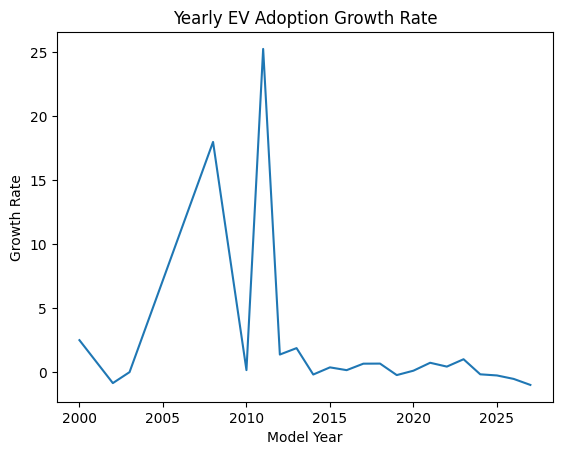

In [35]:
import matplotlib.pyplot as plt
growth = df.groupby('Model Year').size().pct_change()

growth.plot()

plt.title("Yearly EV Adoption Growth Rate")
plt.xlabel("Model Year")
plt.ylabel("Growth Rate")

plt.show()

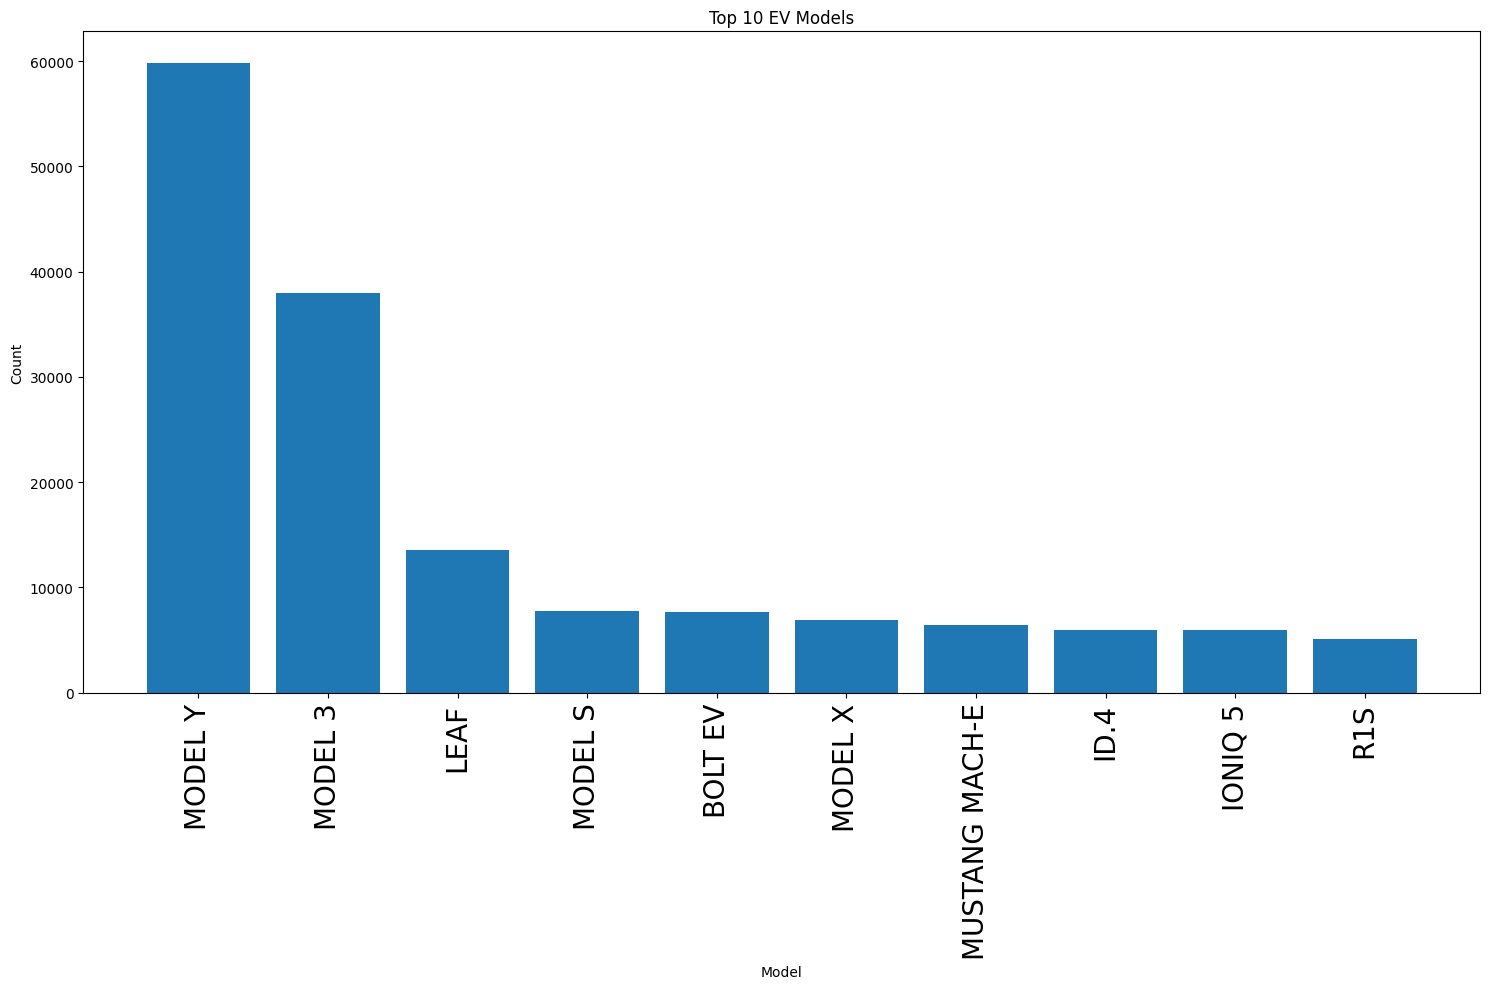

In [36]:
import matplotlib.pyplot as plt

# Get top 10 most common models
model_counts = df_cleaned['Model'].value_counts().head(10)

# Create figure
plt.figure(figsize=(15, 10))

# Bar chart
plt.bar(model_counts.index, model_counts.values)

# Titles and labels
plt.title("Top 10 EV Models")
plt.xlabel("Model")
plt.ylabel("Count")

# Rotate model names
plt.xticks(rotation=90, fontsize=20)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

<Axes: xlabel='Electric Vehicle Type', ylabel='Electric Range'>

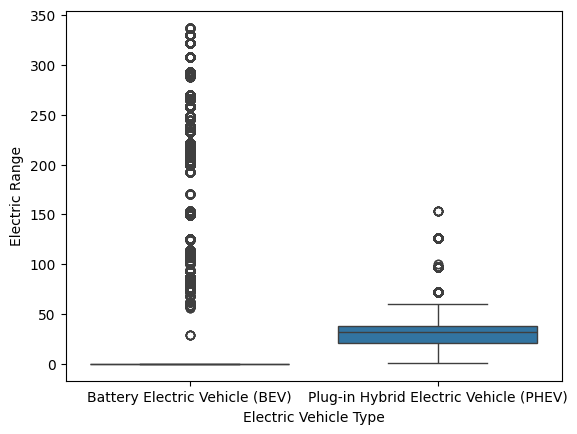

In [37]:
import seaborn as sns
sns.boxplot(x='Electric Vehicle Type', y='Electric Range', data=df_cleaned)


Battery Electric Vehicles tend to have higher electric ranges than Plug-in Hybrid Electric Vehicles and there are no anomalies.

<Axes: xlabel='Model Year', ylabel='Electric Range'>

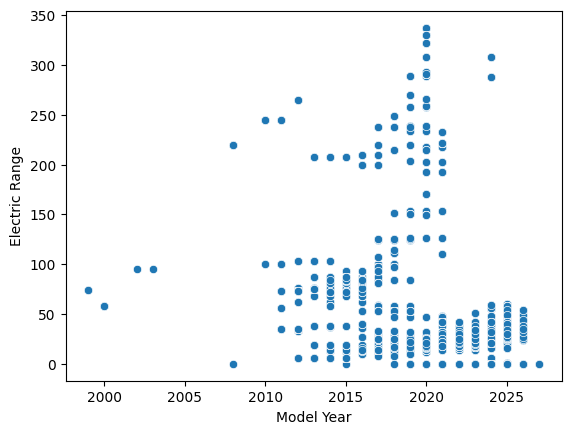

In [38]:
sns.scatterplot(x='Model Year', y='Electric Range', data=df_cleaned)

The above scatterplot shows whether new vehicled have better range in terms of distance covered, hence concluding that,Electric range generally improves in newer model years, suggesting technological advancements.

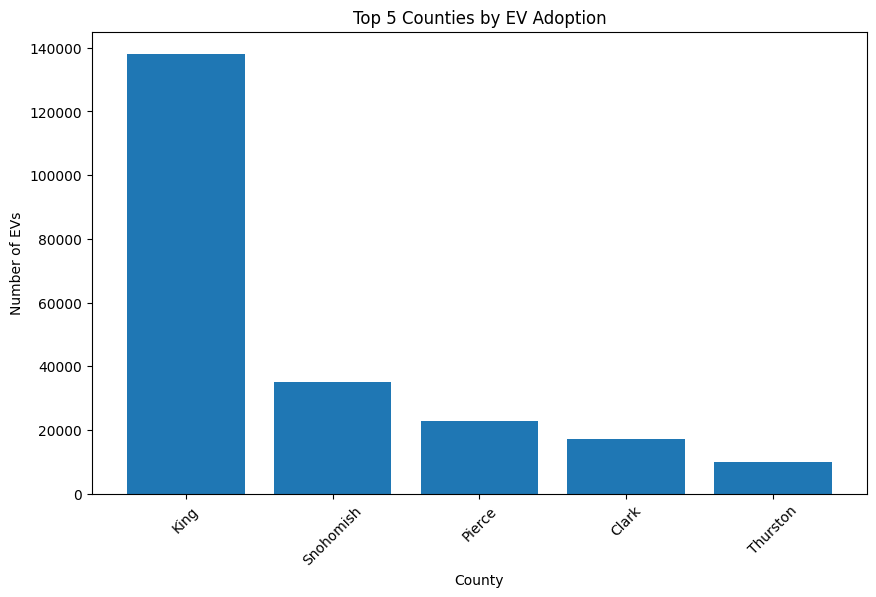

In [39]:
top_counties = df_cleaned['County'].value_counts().head(5)
plt.figure(figsize=(10,6))

plt.bar(top_counties.index, top_counties.values)

plt.title("Top 5 Counties by EV Adoption")
plt.xlabel("County")
plt.ylabel("Number of EVs")

plt.xticks(rotation=45)

plt.show()

King County shows the highest EV adoption, likely due to good urban infrastructure(roads) and policy support

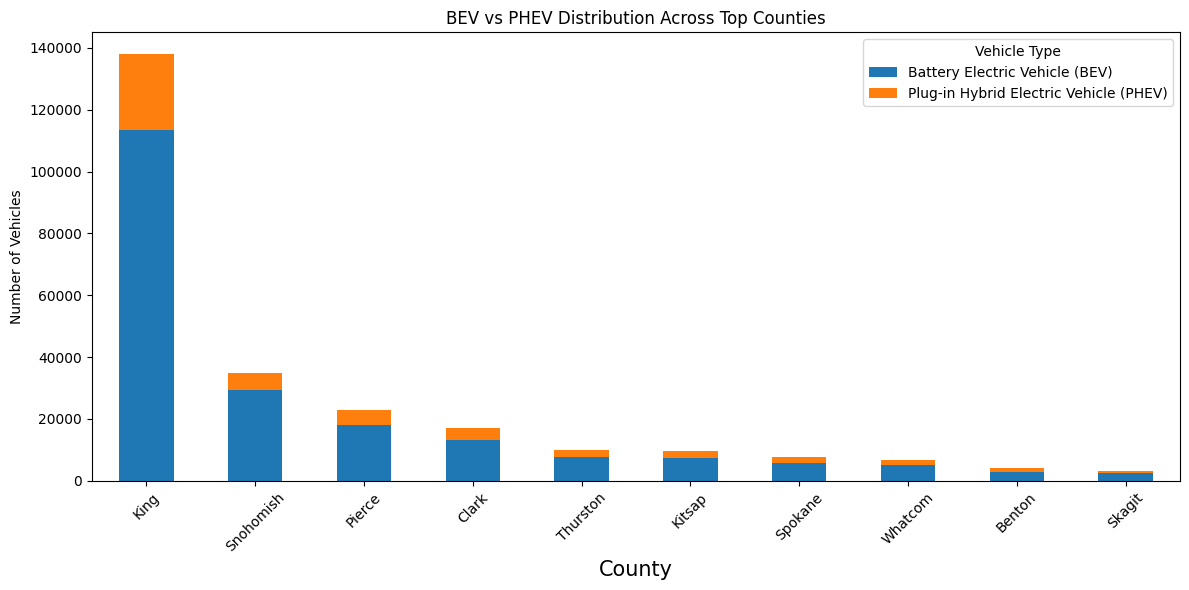

In [59]:
import matplotlib.pyplot as plt

# Get top 10 counties by total EV count
top_counties = df_cleaned['County'].value_counts().head(10).index

# Filter dataset
df_top = df_cleaned[df_cleaned['County'].isin(top_counties)]

# Group by County and Vehicle Type
county_stack = df_top.groupby(
    ['County', 'Electric Vehicle Type']
).size().unstack(fill_value=0)

# Sort for better visualization
county_stack = county_stack.loc[county_stack.sum(axis=1).sort_values(ascending=False).index]

# Plot stacked bar chart
county_stack.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('BEV vs PHEV Distribution Across Top Counties')
plt.xlabel('County', fontsize=15)
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type')
plt.tight_layout()

plt.show()

The choropleth map shows that EV adoption is concentrated in a few high-performing states (yellow regions), while several states still exhibit relatively low adoption levels (blue regions).

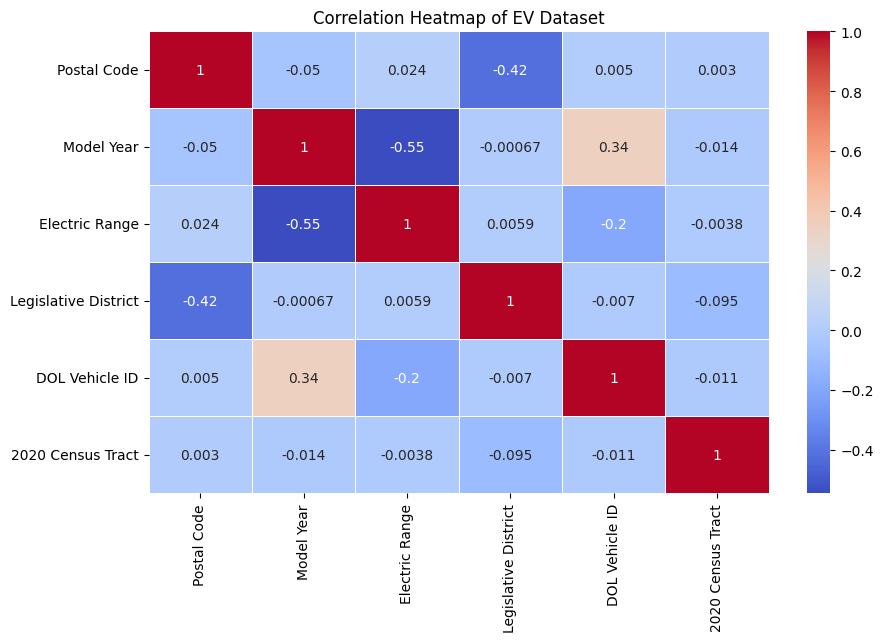

In [42]:
# Select only numeric columns
numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap of EV Dataset")
plt.show()

This correlation heatmap shows the strength and direction of relationships between numerical variables in the EV dataset, helping identify which features are strongly linked, weakly related, or independent of each other

In [53]:
df_cleaned['County']

,County
0,Stevens
1,Yakima
2,King
3,Kitsap
4,Thurston
...,...
279775,Clark
279776,King
279777,King
279778,Pierce
